# สรุปการทำความสะอาดข้อมูลและ EDA ใน CRISP-DM

## กรอบงาน CRISP-DM (Cross Industry Standard Process for Data Mining)
```
1. Business Understanding  → เข้าใจเป้าหมาย
2. Data Understanding      → สำรวจข้อมูล (EDA)
3. Data Preparation        → ทำความสะอาด / แปลงข้อมูล  ← หัวข้อหลัก
4. Modeling                → สร้างโมเดล
5. Evaluation              → ประเมินผล
6. Deployment              → นำไปใช้งาน
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer, LabelEncoder, OneHotEncoder

# สร้าง Dataset ตัวอย่างสำหรับทดสอบ
np.random.seed(42)
data = {
    'age':    [25, 30, np.nan, 45, 200, 35, 28, np.nan, 52, 33],
    'salary': [50000, 60000, 55000, np.nan, 70000, 65000, 48000, 72000, np.nan, 58000],
    'score':  [8.5, 7.2, 9.0, 6.5, 8.0, np.nan, 7.8, 9.5, 6.0, 8.2],
    'gender': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', np.nan, 'M'],
    'city':   ['BKK', 'CM', 'BKK', 'KK', 'BKK', 'CM', 'BKK', 'CM', 'KK', 'BKK']
}
df = pd.DataFrame(data)
print("DataFrame ตัวอย่าง:")
df

DataFrame ตัวอย่าง:


,age,salary,score,gender,city
0,25.0,50000.0,8.5,M,BKK
1,30.0,60000.0,7.2,F,CM
2,NaN,55000.0,9.0,M,BKK
3,45.0,NaN,6.5,F,KK
4,200.0,70000.0,8.0,M,BKK
5,35.0,65000.0,NaN,F,CM
6,28.0,48000.0,7.8,M,BKK
7,NaN,72000.0,9.5,F,CM
8,52.0,NaN,6.0,NaN,KK
9,33.0,58000.0,8.2,M,BKK


---
## ส่วนที่ 1: การตรวจสอบข้อมูลเบื้องต้น (Data Understanding)

In [2]:
# 1.1 ภาพรวมโครงสร้างข้อมูล
print("=== df.shape ===")
print(df.shape)           # (แถว, คอลัมน์)

print("\n=== df.dtypes ===")
print(df.dtypes)          # ชนิดข้อมูลแต่ละคอลัมน์

print("\n=== df.info() ===")
df.info()                 # Non-null count + dtype รวมกัน

=== df.shape ===
(10, 5)

=== df.dtypes ===
age       float64
salary    float64
score     float64
gender     object
city       object
dtype: object

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     8 non-null      float64
 1   salary  8 non-null      float64
 2   score   9 non-null      float64
 3   gender  9 non-null      object 
 4   city    10 non-null     object 
dtypes: float64(3), object(2)
memory usage: 532.0+ bytes


In [3]:
# 1.2 สถิติพื้นฐาน
# df.describe()
#   include='all'   → รวม object/category ด้วย
#   percentiles=[.25,.5,.75] → ปรับ percentile ที่แสดง (default)
df.describe(include='all')

,age,salary,score,gender,city
count,8.000000,8.000000,9.000000,9,10
unique,NaN,NaN,NaN,2,3
top,NaN,NaN,NaN,M,BKK
freq,NaN,NaN,NaN,5,5
mean,56.000000,59750.000000,7.855556,NaN,NaN
std,58.875171,8795.290948,1.133701,NaN,NaN
min,25.000000,48000.000000,6.000000,NaN,NaN
25%,29.500000,53750.000000,7.200000,NaN,NaN
50%,34.000000,59000.000000,8.000000,NaN,NaN
75%,46.750000,66250.000000,8.500000,NaN,NaN


In [4]:
# 1.3 ตรวจสอบ Missing Values
print("จำนวน NaN แต่ละคอลัมน์:")
print(df.isnull().sum())

print("\nเปอร์เซ็นต์ NaN:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nแถวที่มี NaN อย่างน้อย 1 ค่า:")
print(df[df.isnull().any(axis=1)])

จำนวน NaN แต่ละคอลัมน์:
age       2
salary    2
score     1
gender    1
city      0
dtype: int64

เปอร์เซ็นต์ NaN:
age       20.0
salary    20.0
score     10.0
gender    10.0
city       0.0
dtype: float64

แถวที่มี NaN อย่างน้อย 1 ค่า:
    age   salary  score gender city
2   NaN  55000.0    9.0      M  BKK
3  45.0      NaN    6.5      F   KK
5  35.0  65000.0    NaN      F   CM
7   NaN  72000.0    9.5      F   CM
8  52.0      NaN    6.0    NaN   KK


In [5]:
# 1.4 ตรวจสอบ Duplicates
print("จำนวนแถวซ้ำ:", df.duplicated().sum())

# df.duplicated(subset=['col1','col2'], keep='first'/'last'/False)
#   subset  → ระบุคอลัมน์ที่ใช้เช็ค (default=ทุกคอลัมน์)
#   keep    → 'first'=เก็บแรก, 'last'=เก็บหลัง, False=ทุกตัวเป็น True
print(df[df.duplicated(keep=False)])

จำนวนแถวซ้ำ: 0
Empty DataFrame
Columns: [age, salary, score, gender, city]
Index: []


---
## ส่วนที่ 2: การจัดการ Missing Values

In [6]:
df_clean = df.copy()

# ==========================================
# 2.1 วิธีที่ 1: ลบแถว/คอลัมน์ที่มี NaN
# ==========================================
# df.dropna()
#   axis    → 0=ลบแถว (default), 1=ลบคอลัมน์
#   how     → 'any'=ถ้ามี NaN แม้ค่าเดียว, 'all'=NaN ทั้งหมดถึงลบ
#   thresh  → เก็บแถวที่มีค่า non-NaN อย่างน้อย N ค่า
#   subset  → ระบุคอลัมน์ที่ตรวจ

df_drop_any = df.dropna()                        # ลบแถวที่มี NaN ใดก็ได้
df_drop_all = df.dropna(how='all')               # ลบแถวที่ NaN ทั้งหมด
df_drop_thresh = df.dropna(thresh=4)             # เก็บแถวที่มีข้อมูล >= 4 ค่า
df_drop_col = df.dropna(axis=1)                  # ลบคอลัมน์ที่มี NaN
print(f"Original: {df.shape}, After dropna: {df_drop_any.shape}")

Original: (10, 5), After dropna: (5, 5)


In [7]:
# ==========================================
# 2.2 วิธีที่ 2: เติมด้วยค่าคงที่
# ==========================================
# df.fillna(value)
#   value   → ค่าที่ต้องการเติม (ตัวเลข, string, dict)
#   method  → 'ffill'=ใช้ค่าก่อนหน้า, 'bfill'=ใช้ค่าถัดไป (deprecated ใน pandas>=2)
#   limit   → จำกัดจำนวน NaN ต่อเนื่องที่เติม
#   axis    → 0=เติมตามแนวแถว, 1=เติมตามแนวคอลัมน์

df_fill_zero = df.fillna(0)                      # เติมด้วย 0
df_fill_dict = df.fillna({'age': 0, 'gender': 'Unknown'})  # เติมต่างค่าต่างคอลัมน์

# Forward fill / Backward fill
df_ffill = df.ffill()       # เติมด้วยค่าแถวก่อนหน้า
df_bfill = df.bfill()       # เติมด้วยค่าแถวถัดไป
print("เติมด้วย dict:")
print(df_fill_dict[['age','gender']])

เติมด้วย dict:
     age   gender
0   25.0        M
1   30.0        F
2    0.0        M
3   45.0        F
4  200.0        M
5   35.0        F
6   28.0        M
7    0.0        F
8   52.0  Unknown
9   33.0        M


In [8]:
# ==========================================
# 2.3 วิธีที่ 3: เติมด้วย Mean / Median / Mode
# ==========================================
# เมื่อไรใช้อะไร:
#   Mean   → ข้อมูลปกติ ไม่มี outlier
#   Median → มี outlier หรือ skewed distribution
#   Mode   → ข้อมูล categorical หรือ discrete

df_impute = df.copy()

# Mean
df_impute['age'].fillna(df_impute['age'].mean(), inplace=True)
print(f"Mean age: {df['age'].mean():.2f}")

# Median
df_impute['salary'].fillna(df_impute['salary'].median(), inplace=True)
print(f"Median salary: {df['salary'].median():.2f}")

# Mode (categorical)
df_impute['gender'].fillna(df_impute['gender'].mode()[0], inplace=True)
print(f"Mode gender: {df['gender'].mode()[0]}")

df_impute

Mean age: 56.00
Median salary: 59000.00
Mode gender: M


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64457/3123574839.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_impute['age'].fillna(df_impute['age'].mean(), inplace=True)
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64457/3123574839.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are set

,age,salary,score,gender,city
0,25.0,50000.0,8.5,M,BKK
1,30.0,60000.0,7.2,F,CM
2,56.0,55000.0,9.0,M,BKK
3,45.0,59000.0,6.5,F,KK
4,200.0,70000.0,8.0,M,BKK
5,35.0,65000.0,NaN,F,CM
6,28.0,48000.0,7.8,M,BKK
7,56.0,72000.0,9.5,F,CM
8,52.0,59000.0,6.0,M,KK
9,33.0,58000.0,8.2,M,BKK


In [9]:
# ==========================================
# 2.4 วิธีที่ 4: SimpleImputer (sklearn)
# ==========================================
from sklearn.impute import SimpleImputer, KNNImputer

# SimpleImputer
#   strategy → 'mean', 'median', 'most_frequent', 'constant'
#   fill_value → ค่าที่เติมเมื่อ strategy='constant'
#   missing_values → ค่าที่ถือว่า missing (default=np.nan)

num_imputer = SimpleImputer(strategy='median')  # เติม median
df_num = df[['age', 'salary', 'score']]
df_imputed_num = pd.DataFrame(
    num_imputer.fit_transform(df_num), 
    columns=df_num.columns
)
print("After SimpleImputer(median):")
print(df_imputed_num)

# KNNImputer - เติมโดยดูจาก K เพื่อนบ้านที่ใกล้ที่สุด
#   n_neighbors → จำนวนเพื่อนบ้าน (default=5)
#   weights     → 'uniform'=เท่ากัน, 'distance'=ถ่วงน้ำหนักตามระยะ
knn_imputer = KNNImputer(n_neighbors=3, weights='distance')
df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df_num),
    columns=df_num.columns
)
print("\nAfter KNNImputer(k=3):")
print(df_knn)

After SimpleImputer(median):
     age   salary  score
0   25.0  50000.0    8.5
1   30.0  60000.0    7.2
2   34.0  55000.0    9.0
3   45.0  59000.0    6.5
4  200.0  70000.0    8.0
5   35.0  65000.0    8.0
6   28.0  48000.0    7.8
7   34.0  72000.0    9.5
8   52.0  59000.0    6.0
9   33.0  58000.0    8.2

After KNNImputer(k=3):
          age        salary     score
0   25.000000  50000.000000  8.500000
1   30.000000  60000.000000  7.200000
2   48.172065  55000.000000  9.000000
3   45.000000  62078.338443  6.500000
4  200.000000  70000.000000  8.000000
5   35.000000  65000.000000  6.316388
6   28.000000  48000.000000  7.800000
7   48.403930  72000.000000  9.500000
8   52.000000  62329.092352  6.000000
9   33.000000  58000.000000  8.200000


---
## ส่วนที่ 3: การจัดการ Outliers

In [10]:
# ==========================================
# 3.1 ตรวจหา Outlier ด้วย IQR
# ==========================================
col = 'age'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Range: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers:\n{outliers}")

# ตัวคูณ 1.5 = mild outlier, 3.0 = extreme outlier

Q1=29.5, Q3=46.75, IQR=17.25
Range: [3.6, 72.6]
Outliers:
     age   salary  score gender city
4  200.0  70000.0    8.0      M  BKK


In [11]:
# ==========================================
# 3.2 ตรวจหา Outlier ด้วย Z-score
# ==========================================
from scipy import stats

# |z-score| > 3 → outlier
df_imputed = df_impute.copy()
z_scores = np.abs(stats.zscore(df_imputed[['age', 'salary', 'score']]))
df_no_outlier_z = df_imputed[(z_scores < 3).all(axis=1)]
print(f"ก่อน: {df_imputed.shape}, หลังลบ outlier: {df_no_outlier_z.shape}")

ก่อน: (10, 5), หลังลบ outlier: (0, 5)


In [12]:
# ==========================================
# 3.3 จัดการ Outlier - Capping / Winsorizing
# ==========================================
# แทนที่จะลบ → cap ค่าให้อยู่ในช่วงที่ยอมรับได้
df_capped = df_imputed.copy()
df_capped['age'] = df_capped['age'].clip(lower=lower, upper=upper)
#   clip(lower, upper) → ค่าต่ำกว่า lower จะกลายเป็น lower, สูงกว่า upper กลายเป็น upper
print(df_capped['age'])

0    25.000
1    30.000
2    56.000
3    45.000
4    72.625
5    35.000
6    28.000
7    56.000
8    52.000
9    33.000
Name: age, dtype: float64


---
## ส่วนที่ 4: การทำ Feature Scaling

In [13]:
_cols = ['age', 'salary', 'score']
df_scale = df_imputed[_cols].fillna(df_imputed[_cols].median()).copy()

# ==========================================
# 4.1 StandardScaler (Z-score Normalization)
# ==========================================
# สูตร: z = (x - mean) / std  → ผลลัพธ์ mean=0, std=1
# เหมาะกับ: อัลกอริทึมที่สมมติ normal distribution (SVM, linear/logistic regression, PCA)
# ไม่เหมาะกับ: มี outlier มาก
#
# Parameters:
#   with_mean=True  → ลบ mean (default=True)
#   with_std=True   → หาร std  (default=True)
scaler_std = StandardScaler(with_mean=True, with_std=True)
df_std = pd.DataFrame(scaler_std.fit_transform(df_scale), columns=df_scale.columns)
print("StandardScaler result:")
print(df_std.describe().round(2))

StandardScaler result:
         age  salary  score
count  10.00   10.00  10.00
mean   -0.00    0.00  -0.00
std     1.05    1.05   1.05
min    -0.63   -1.58  -1.84
25%    -0.51   -0.52  -0.51
50%    -0.32   -0.08   0.13
75%    -0.02    0.56   0.55
max     2.92    1.68   1.61


In [14]:
# ==========================================
# 4.2 MinMaxScaler (Min-Max Normalization)
# ==========================================
# สูตร: x_new = (x - min) / (max - min)  → ผลลัพธ์ [0, 1]
# เหมาะกับ: Neural network, KNN, Image processing
# ไม่เหมาะกับ: มี outlier มาก (outlier กดให้ค่าอื่นเล็กมาก)
#
# Parameters:
#   feature_range=(0,1)  → ช่วงผลลัพธ์ (default=(0,1))
scaler_mm = MinMaxScaler(feature_range=(0, 1))
df_mm = pd.DataFrame(scaler_mm.fit_transform(df_scale), columns=df_scale.columns)
print("MinMaxScaler result (range 0-1):")
print(df_mm.describe().round(3))

MinMaxScaler result (range 0-1):
          age  salary   score
count  10.000  10.000  10.000
mean    0.177   0.483   0.534
std     0.297   0.323   0.306
min     0.000   0.000   0.000
25%     0.033   0.323   0.386
50%     0.086   0.458   0.571
75%     0.171   0.656   0.693
max     1.000   1.000   1.000


In [15]:
# ==========================================
# 4.3 RobustScaler
# ==========================================
# สูตร: x_new = (x - median) / IQR
# เหมาะกับ: มี outlier จำนวนมาก (ใช้ median/IQR แทน mean/std)
#
# Parameters:
#   with_centering=True      → ลบ median (default=True)
#   with_scaling=True        → หาร IQR    (default=True)
#   quantile_range=(25,75)   → ช่วง IQR ที่ใช้ (default=(25,75))
scaler_rob = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0))
df_rob = pd.DataFrame(scaler_rob.fit_transform(df_scale), columns=df_scale.columns)
print("RobustScaler result:")
print(df_rob.describe().round(3))

RobustScaler result:
          age  salary   score
count  10.000  10.000  10.000
mean    0.660   0.075  -0.121
std     2.141   0.970   0.995
min    -0.619  -1.375  -1.860
25%    -0.381  -0.406  -0.605
50%     0.000   0.000   0.000
75%     0.619   0.594   0.395
max     6.598   1.625   1.395


In [16]:
# ==========================================
# 4.4 Normalizer (L-norm Normalization)
# ==========================================
# ทำ normalize แต่ละ ROW (ไม่ใช่คอลัมน์!) ให้ norm=1
# เหมาะกับ: Text classification, Cosine similarity, NLP
#
# Parameters:
#   norm → 'l1', 'l2' (default), 'max'
#     l1  = sum(|x|) = 1  (Manhattan)
#     l2  = sqrt(sum(x^2)) = 1  (Euclidean)
#     max = max(|x|) = 1
normalizer_l2 = Normalizer(norm='l2')
df_norm = pd.DataFrame(normalizer_l2.fit_transform(df_scale), columns=df_scale.columns)
print("Normalizer(l2) result (each row normalized):")
print(df_norm.head())
print("\nRow norms (should be ~1.0):")
print(np.sqrt((df_norm**2).sum(axis=1)).head())

Normalizer(l2) result (each row normalized):
        age    salary     score
0  0.000500  1.000000  0.000170
1  0.000500  1.000000  0.000120
2  0.001018  0.999999  0.000164
3  0.000763  1.000000  0.000110
4  0.002857  0.999996  0.000114

Row norms (should be ~1.0):
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


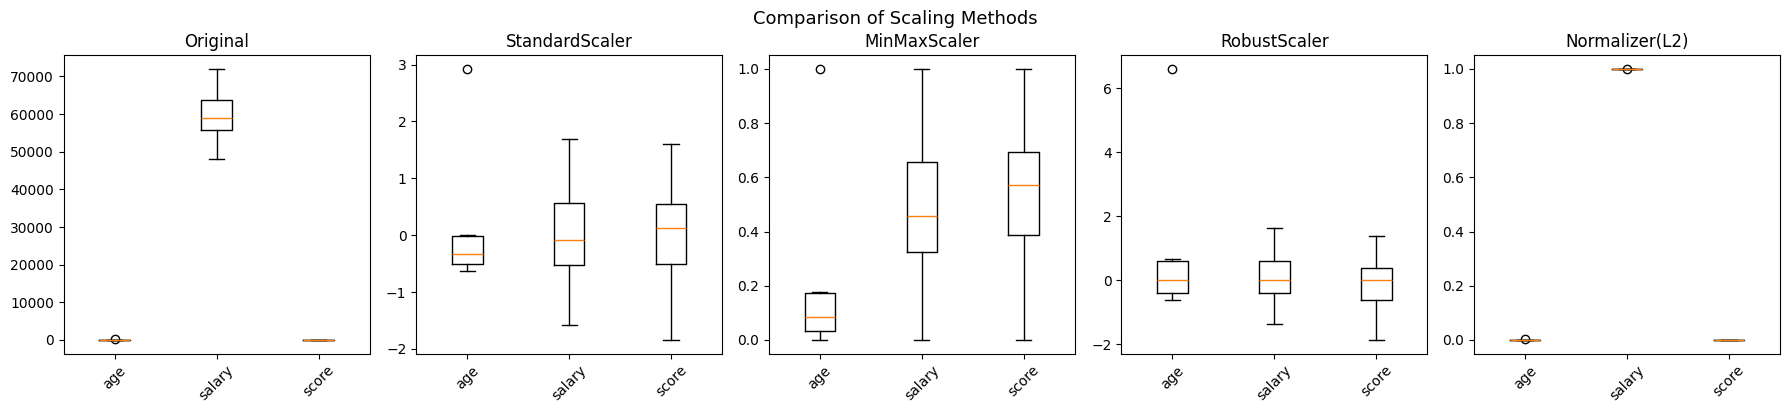

In [17]:
# เปรียบเทียบ Scaling Methods แบบภาพ
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
datasets = [df_scale, df_std, df_mm, df_rob, df_norm]
titles = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler', 'Normalizer(L2)']

for ax, data, title in zip(axes, datasets, titles):
    ax.boxplot(data.values)
    ax.set_xticklabels(data.columns, rotation=45)
    ax.set_title(title)

plt.tight_layout()
plt.suptitle('Comparison of Scaling Methods', y=1.02, fontsize=13)
plt.show()

### สรุปการเลือก Scaler

| Scaler | สูตร | เหมาะกับ | ระวัง |
|--------|------|----------|-------|
| StandardScaler | (x-mean)/std | SVM, LR, PCA, Neural Net | ไม่ดีถ้ามี outlier มาก |
| MinMaxScaler | (x-min)/(max-min) | KNN, Neural Net, Images | outlier กดค่าอื่น |
| RobustScaler | (x-median)/IQR | ข้อมูลมี outlier | range ไม่แน่นอน |
| Normalizer | แต่ละ row / norm | Text, Cosine sim | normalize row ไม่ใช่ col |

---
## ส่วนที่ 5: การ Encode ตัวแปร Categorical

In [18]:
df_cat = df_imputed.copy()

# ==========================================
# 5.1 Label Encoding (Ordinal)
# ==========================================
# แปลง category → ตัวเลข 0, 1, 2, ...
# เหมาะกับ: ordinal data (เล็ก/กลาง/ใหญ่) หรือ tree-based models
# ไม่เหมาะกับ: linear models (เพราะ encode ลำดับที่ไม่มีความหมาย)
le = LabelEncoder()
df_cat['gender_encoded'] = le.fit_transform(df_cat['gender'].astype(str))
print("LabelEncoder classes:", le.classes_)
print(df_cat[['gender', 'gender_encoded']])

LabelEncoder classes: ['F' 'M']
  gender  gender_encoded
0      M               1
1      F               0
2      M               1
3      F               0
4      M               1
5      F               0
6      M               1
7      F               0
8      M               1
9      M               1


In [19]:
# ==========================================
# 5.2 One-Hot Encoding
# ==========================================
# แปลงแต่ละ category → คอลัมน์ใหม่ (0/1)
# เหมาะกับ: nominal data (BKK/CM/KK), linear models, neural net
# ระวัง: dummy variable trap → ใช้ drop_first=True ใน pandas

# วิธี pandas (ง่ายกว่า)
df_ohe_pd = pd.get_dummies(df_cat, columns=['city', 'gender'], 
                            drop_first=False,   # True=ลบ 1 คอลัมน์เพื่อหลีก dummy trap
                            prefix=['city', 'gender'],
                            dtype=int)
print("One-Hot Encoding (pandas):")
print(df_ohe_pd.head())

# วิธี sklearn
ohe = OneHotEncoder(drop='first',       # drop='first'=ลบ first category, None=เก็บทั้งหมด
                    sparse_output=False, # False=คืน dense array
                    handle_unknown='ignore')  # ignore=ถ้า test มี category ใหม่ไม่ error
city_encoded = ohe.fit_transform(df_cat[['city']])
print("\nOneHotEncoder (sklearn) categories:", ohe.categories_)

One-Hot Encoding (pandas):
     age   salary  score  gender_encoded  city_BKK  city_CM  city_KK  \
0   25.0  50000.0    8.5               1         1        0        0   
1   30.0  60000.0    7.2               0         0        1        0   
2   56.0  55000.0    9.0               1         1        0        0   
3   45.0  59000.0    6.5               0         0        0        1   
4  200.0  70000.0    8.0               1         1        0        0   

   gender_F  gender_M  
0         0         1  
1         1         0  
2         0         1  
3         1         0  
4         0         1  

OneHotEncoder (sklearn) categories: [array(['BKK', 'CM', 'KK'], dtype=object)]


In [20]:
# ==========================================
# 5.3 Ordinal Encoding
# ==========================================
# กำหนดลำดับเองสำหรับ ordinal data
from sklearn.preprocessing import OrdinalEncoder

size_data = pd.DataFrame({'size': ['S', 'M', 'L', 'XL', 'M', 'S']})
oe = OrdinalEncoder(categories=[['S', 'M', 'L', 'XL']])  # กำหนด order
size_data['size_encoded'] = oe.fit_transform(size_data[['size']])
print(size_data)

  size  size_encoded
0    S           0.0
1    M           1.0
2    L           2.0
3   XL           3.0
4    M           1.0
5    S           0.0


---
## ส่วนที่ 6: การ Explore ข้อมูล (EDA - Exploratory Data Analysis)

In [21]:
# โหลด dataset จริงสำหรับ EDA
tips = sns.load_dataset('tips')
print(tips.head())
print(tips.shape)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


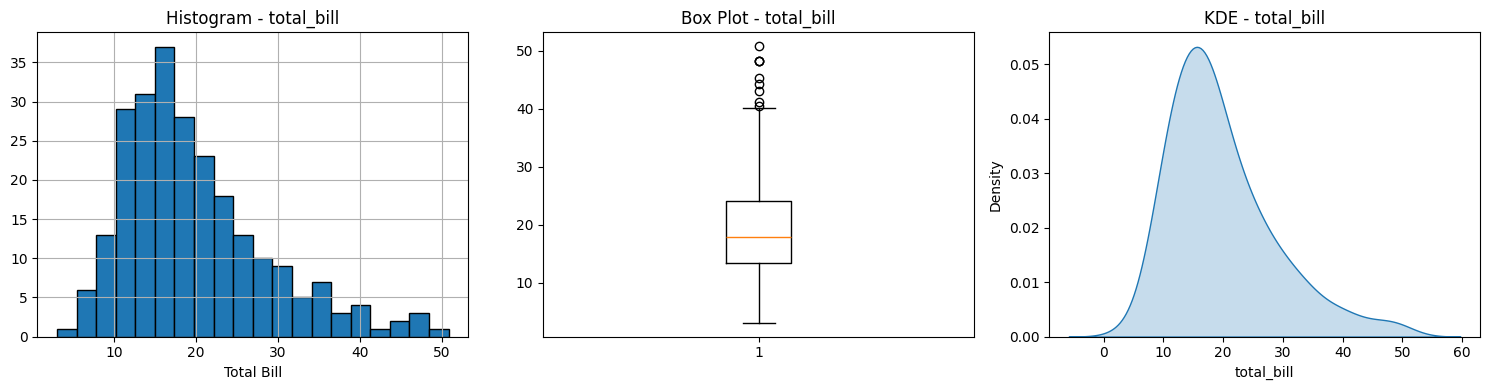

In [22]:
# ==========================================
# 6.1 Univariate Analysis - ตัวแปรเดียว
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
# bins=20         → จำนวนช่วง (auto ถ้าไม่ระบุ)
# kde=True        → แสดง kernel density curve
# color, edgecolor → สี
tips['total_bill'].hist(bins=20, edgecolor='black', ax=axes[0])
axes[0].set_title('Histogram - total_bill')
axes[0].set_xlabel('Total Bill')

# Box Plot
# showfliers=True  → แสดง outlier (default=True)
# vert=True        → แนวตั้ง (default), False=แนวนอน
axes[1].boxplot(tips['total_bill'], showfliers=True, vert=True)
axes[1].set_title('Box Plot - total_bill')

# KDE (Kernel Density Estimation)
# bw_adjust=1.0   → ความกว้าง bandwidth (>1=smooth, <1=รายละเอียดมาก)
# fill=True       → เติมใต้เส้น
sns.kdeplot(data=tips, x='total_bill', bw_adjust=1.0, fill=True, ax=axes[2])
axes[2].set_title('KDE - total_bill')

plt.tight_layout()
plt.show()

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64457/3969729144.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill',


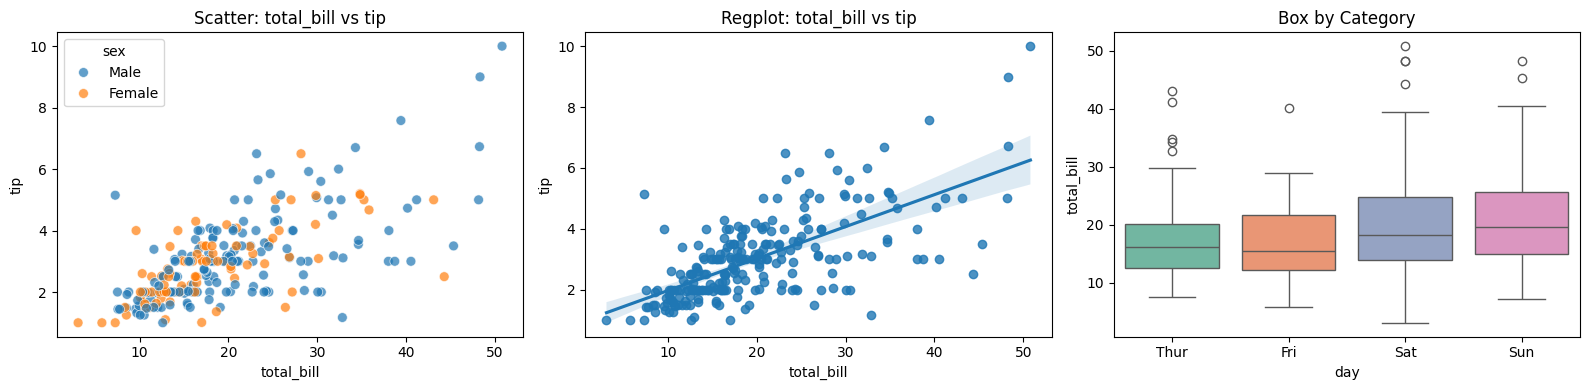

In [23]:
# ==========================================
# 6.2 Bivariate Analysis - 2 ตัวแปร
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter Plot
# alpha=0.7    → ความโปร่งใส 0-1
# s=50         → ขนาด marker
# hue='sex'    → แยกสีตาม category
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex',
                alpha=0.7, s=50, ax=axes[0])
axes[0].set_title('Scatter: total_bill vs tip')

# Regression Plot (scatter + regression line)
# ci=95        → confidence interval (None=ไม่แสดง)
# order=1      → degree ของ polynomial (1=linear)
sns.regplot(data=tips, x='total_bill', y='tip', ci=95, order=1, ax=axes[1])
axes[1].set_title('Regplot: total_bill vs tip')

# Box Plot แยกตาม category
# order=['Thur','Fri','Sat','Sun'] → กำหนดลำดับ x
# palette='Set2' → ชุดสี seaborn
sns.boxplot(data=tips, x='day', y='total_bill',
            order=['Thur', 'Fri', 'Sat', 'Sun'], 
            palette='Set2', ax=axes[2])
axes[2].set_title('Box by Category')

plt.tight_layout()
plt.show()

Correlation Matrix:
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


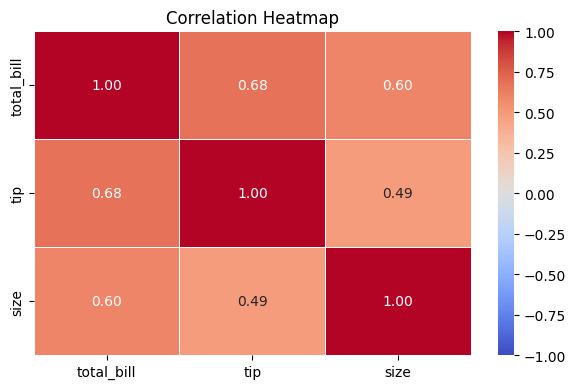

In [24]:
# ==========================================
# 6.3 Correlation Analysis
# ==========================================
# df.corr()
#   method → 'pearson' (default, linear), 'spearman' (rank), 'kendall'
#     Pearson  → ตัวแปร continuous, linear relationship
#     Spearman → มี outlier หรือ monotonic relationship

corr_matrix = tips[['total_bill', 'tip', 'size']].corr(method='pearson')
print("Correlation Matrix:")
print(corr_matrix)

# Heatmap
# annot=True   → แสดงตัวเลขในช่อง
# fmt='.2f'    → format ทศนิยม 2 ตำแหน่ง
# cmap         → colormap ('coolwarm', 'viridis', 'RdBu_r')
# vmin/vmax    → ช่วงสี (-1 ถึง 1 สำหรับ correlation)
# linewidths   → เส้นแบ่งช่อง
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

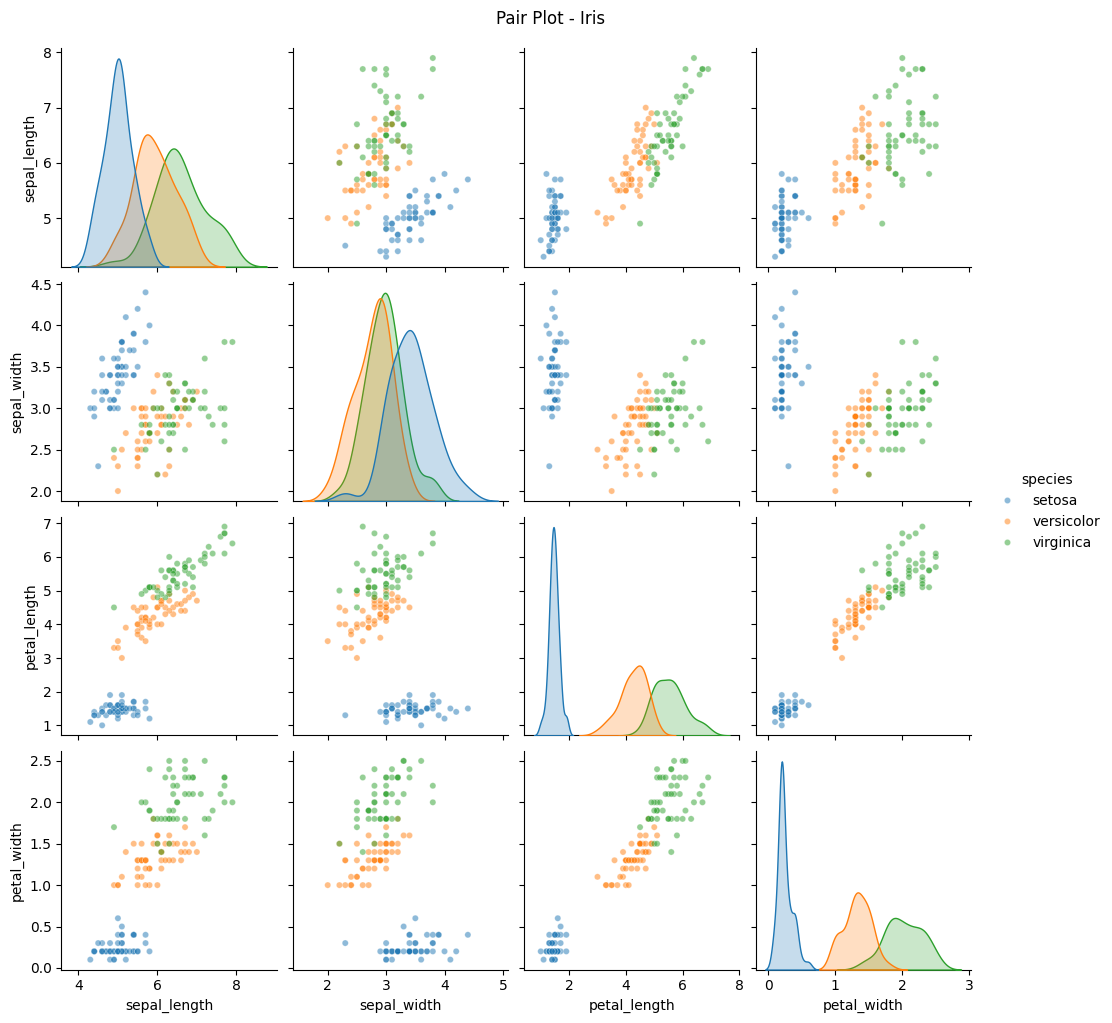

In [25]:
# ==========================================
# 6.4 Multivariate Analysis
# ==========================================

# Pair Plot - ดูความสัมพันธ์ทุกคู่ตัวแปร
# hue='species'   → แยกสีตาม category
# diag_kind       → 'auto', 'hist', 'kde' (กราฟแนวทแยง)
# plot_kws        → kwargs สำหรับ scatter (alpha, s)
iris = sns.load_dataset('iris')
pair_plot = sns.pairplot(iris, hue='species', diag_kind='kde',
                          plot_kws={'alpha': 0.5, 's': 20})
pair_plot.fig.suptitle('Pair Plot - Iris', y=1.02)
plt.show()

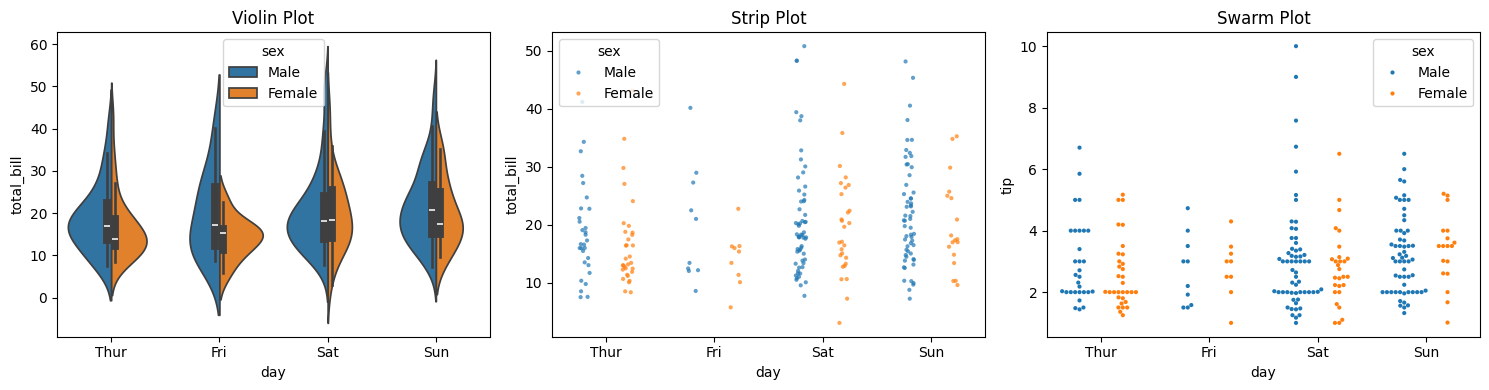

In [26]:
# ==========================================
# 6.5 Distribution Analysis
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Violin Plot = Box + KDE
# split=True   → แสดง 2 hue ซ้อนกัน (ถ้า hue มี 2 ค่า)
# inner        → 'box', 'quart', 'point', 'stick', None
# scale        → 'area', 'count', 'width'
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex',
               inner='box', split=True, ax=axes[0])
axes[0].set_title('Violin Plot')

# Strip Plot - แสดงจุดข้อมูลทุกจุด
# jitter=True  → กระจายจุดไม่ให้ซ้อน (default=True)
# size=3       → ขนาดจุด
# dodge=True   → แยก hue ออกจากกัน
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex',
              jitter=True, size=3, dodge=True, alpha=0.7, ax=axes[1])
axes[1].set_title('Strip Plot')

# Swarm Plot - คล้าย strip แต่ไม่ซ้อนกัน
# size=3       → ขนาดจุด
sns.swarmplot(data=tips, x='day', y='tip', hue='sex',
              size=3, dodge=True, ax=axes[2])
axes[2].set_title('Swarm Plot')

plt.tight_layout()
plt.show()

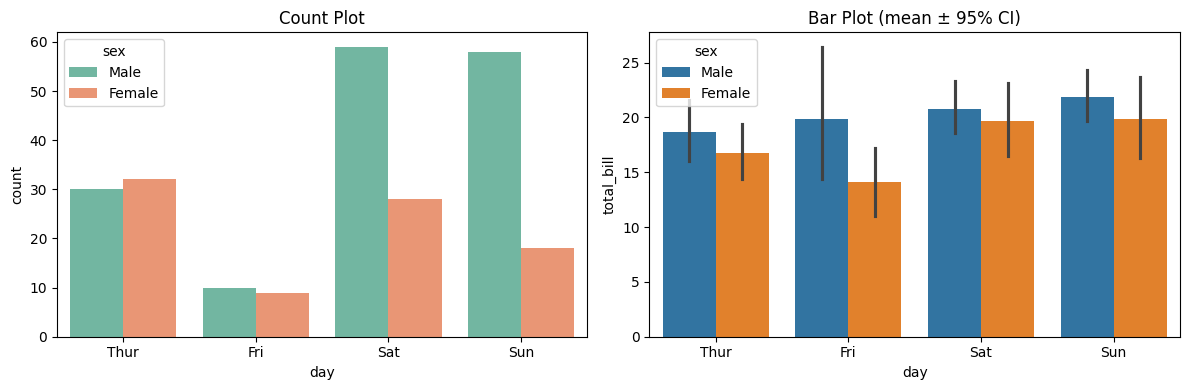

In [27]:
# ==========================================
# 6.6 Categorical Analysis
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count Plot
# order → กำหนดลำดับ bar
# stat='count'/'percent'/'probability'/'proportion'
sns.countplot(data=tips, x='day', hue='sex',
              order=['Thur', 'Fri', 'Sat', 'Sun'],
              palette='Set2', ax=axes[0])
axes[0].set_title('Count Plot')

# Bar Plot (mean + CI)
# estimator=np.mean  → ค่าที่ plot (default=mean)
# errorbar=('ci',95) → confidence interval (None=ไม่แสดง, 'sd'=std dev)
sns.barplot(data=tips, x='day', y='total_bill', hue='sex',
            estimator='mean', errorbar=('ci', 95),
            order=['Thur', 'Fri', 'Sat', 'Sun'], ax=axes[1])
axes[1].set_title('Bar Plot (mean ± 95% CI)')

plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# 6.7 pandas Profiling (Quick EDA)
# ==========================================
# !pip install ydata-profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title='EDA Report', explorative=True)
# profile.to_file('report.html')  # บันทึก HTML
# profile.to_notebook_iframe()    # แสดงใน Jupyter

# Alternative: pandas built-in
print("=== value_counts() ===")
print(tips['day'].value_counts())          # นับความถี่
print("\n=== value_counts(normalize=True) ===")
print(tips['day'].value_counts(normalize=True).round(3))  # เป็น proportion

print("\n=== groupby + describe ===")
print(tips.groupby('day')['total_bill'].describe().round(2))

=== value_counts() ===
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

=== value_counts(normalize=True) ===
day
Sat     0.357
Sun     0.311
Thur    0.254
Fri     0.078
Name: proportion, dtype: float64

=== groupby + describe ===
      count   mean   std   min    25%    50%    75%    max
day                                                       
Thur   62.0  17.68  7.89  7.51  12.44  16.20  20.16  43.11
Fri    19.0  17.15  8.30  5.75  12.10  15.38  21.75  40.17
Sat    87.0  20.44  9.48  3.07  13.90  18.24  24.74  50.81
Sun    76.0  21.41  8.83  7.25  14.99  19.63  25.60  48.17


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64457/3799681510.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby('day')['total_bill'].describe().round(2))


---
## ส่วนที่ 7: การจัดการชนิดข้อมูล (Data Type Handling)

In [29]:
# ==========================================
# 7.1 แปลงชนิดข้อมูล
# ==========================================
sample = pd.DataFrame({
    'age': ['25', '30', '35'],
    'price': ['1,500.50', '2,000', '3,750.25'],
    'date': ['2024-01-15', '2024-06-30', '2024-12-01'],
    'category': ['A', 'B', 'A']
})

# แปลงเป็นตัวเลข
sample['age'] = sample['age'].astype(int)
sample['price'] = sample['price'].str.replace(',', '').astype(float)

# แปลงเป็น datetime
# format → กำหนด format เอง ('%Y-%m-%d', '%d/%m/%Y' ฯลฯ)
# errors → 'raise'=error, 'coerce'=แปลงไม่ได้ → NaT, 'ignore'=ไม่แปลง
sample['date'] = pd.to_datetime(sample['date'], format='%Y-%m-%d', errors='coerce')

# แปลงเป็น Category (ลด memory)
sample['category'] = sample['category'].astype('category')

print(sample.dtypes)
print(sample)

age                  int64
price              float64
date        datetime64[ns]
category          category
dtype: object
   age    price       date category
0   25  1500.50 2024-01-15        A
1   30  2000.00 2024-06-30        B
2   35  3750.25 2024-12-01        A


---
## สรุปรวม: Checklist การทำ Data Preparation ใน CRISP-DM

```
Phase: Data Understanding
  □ df.shape, df.info(), df.describe(include='all')
  □ df.isnull().sum()      → ตรวจ missing
  □ df.duplicated().sum()  → ตรวจซ้ำ
  □ EDA: histogram, boxplot, scatter, heatmap

Phase: Data Preparation
  □ จัดการ Missing Values:
      - dropna()           → ถ้า % น้อยและสุ่ม
      - fillna(mean)       → numerical ไม่มี outlier
      - fillna(median)     → numerical มี outlier
      - fillna(mode)       → categorical
      - KNNImputer         → มีความสัมพันธ์กับคอลัมน์อื่น
  □ จัดการ Outliers:
      - ตรวจด้วย IQR หรือ Z-score
      - ลบ / Capping / Transform (log)
  □ Feature Encoding:
      - LabelEncoder       → ordinal / tree-based models
      - OneHotEncoder      → nominal / linear models
  □ Feature Scaling:
      - StandardScaler     → SVM, LR, PCA
      - MinMaxScaler       → KNN, Neural Net
      - RobustScaler       → มี outlier
  □ ตรวจสอบ data types ให้ถูกต้อง
  □ ลบ columns ที่ไม่จำเป็น
  □ แบ่ง train/test ก่อน fit scaler/imputer!
```

> **หลักสำคัญ:** fit() บน train set เท่านั้น แล้วค่อย transform() ทั้ง train และ test
> เพื่อป้องกัน **data leakage**